Naor Bitton - Project C - Data Analysis

# 3.1 - Project overview & Data # 
---
**<span style="color:royalblue">Project</span> <span style="color:gold">Goal:</span>**
 **<span style="color:royalblue">Stephen Curry</span> <span style="color:gold">Playoff 2022</span>**
-
​**Research Question:**
How did Stephen Curry maintain elite scoring efficiency 
<br>during the 2022 Playoffs despite facing extreme Defensive Pressure?

**​Research Objectives:**
<br>**Efficiency vs. Pressure & Fatigue:** 
<br>Analyze the correlation between Minutes Played (MP) and Effective Field Goal Percentage (eFG%) 
<br>among top NBA stars to see who stays efficient as physical fatigue increases.
​<br>Offensive Load Analysis: Compare Curry scoring output (PTS) and shot attempts (FGA) 
<br>to prove he remained the primary engine even when defenses focused on him.
<br>​The "Clutch" Proxy: Using eFG% to demonstrate high-level decision-making 
<br>and shooting accuracy despite heavy fatigue in critical moments.

**Data Source:**   
NBA Playoff Stats 2022 (CSV file).
The dataset includes variables such as:
* Player names, teams, and positions.
* Scoring stats (Points, FG%, 3P%).
* Minutes & Games: Total minutes played and games started.


**<span style="color:lightgreen">3.2 - Library Imports</span>**
-
**Importing essential libraries for data manipulation:** 
<br>(Pandas, Numpy) 
<br>**and data visualization:** 
<br>(Matplotlib, Seaborn).

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.lines as mlines

**<span style="color:lightgreen">3.2 - Data Loading**</span>
-
In this stage, I imported the 2022 NBA Playoff dataset.  
I used the **sep** and **encoding** parameters to ensure   
the data was loaded correctly and successfully.

In [4]:
df = pd.read_csv('Nba_2022.csv', sep=';', encoding='ISO-8859-1')

**<span style="color:lightgreen">3.3 - Key Insights from EDA:**</span>
-
**League Baseline:** The average player plays 19 minutes with a 43.7% eFG%.   
**The Challenge:** I will use these averages to show how Curry maintains elite  
efficiency despite playing much heavier minutes and facing higher defensive   
pressure than the average player.


In [5]:
df.describe()

,Rk,Age,G,GS,MP,FG,FGA,FG%,3P,3PA,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
count,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,...,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000
mean,109.000000,26.589862,8.714286,4.009217,19.429032,3.045161,6.737788,0.437516,0.934562,2.700461,...,0.623249,0.773733,2.626728,3.404147,1.828571,0.584793,0.361290,1.085714,1.784332,8.457143
std,62.786676,4.238545,5.802412,5.944178,12.879892,2.699843,5.865455,0.184581,0.969323,2.538454,...,0.344243,0.848965,2.203811,2.842360,2.007120,0.499629,0.453458,1.126790,1.175811,7.625418
min,1.000000,19.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,23.000000,5.000000,0.000000,7.600000,1.000000,2.000000,0.370000,0.000000,0.500000,...,0.500000,0.200000,1.000000,1.200000,0.400000,0.200000,0.000000,0.300000,0.800000,2.100000
50%,109.000000,26.000000,6.000000,0.000000,18.400000,2.300000,4.700000,0.439000,0.700000,2.200000,...,0.750000,0.500000,2.000000,2.800000,1.000000,0.500000,0.200000,0.800000,1.800000,6.000000
75%,163.000000,29.000000,12.000000,6.000000,31.200000,4.500000,10.000000,0.500000,1.500000,4.400000,...,0.857000,1.000000,3.700000,4.800000,2.700000,0.900000,0.500000,1.500000,2.800000,12.600000
max,217.000000,38.000000,24.000000,24.000000,44.000000,12.200000,23.800000,1.000000,4.100000,10.400000,...,1.000000,5.500000,12.000000,14.300000,9.800000,2.100000,2.500000,6.200000,4.700000,31.700000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rk      217 non-null    int64  
 1   Player  217 non-null    str    
 2   Pos     217 non-null    str    
 3   Age     217 non-null    int64  
 4   Tm      217 non-null    str    
 5   G       217 non-null    int64  
 6   GS      217 non-null    int64  
 7   MP      217 non-null    float64
 8   FG      217 non-null    float64
 9   FGA     217 non-null    float64
 10  FG%     217 non-null    float64
 11  3P      217 non-null    float64
 12  3PA     217 non-null    float64
 13  3P%     217 non-null    float64
 14  2P      217 non-null    float64
 15  2PA     217 non-null    float64
 16  2P%     217 non-null    float64
 17  eFG%    217 non-null    float64
 18  FT      217 non-null    float64
 19  FTA     217 non-null    float64
 20  FT%     217 non-null    float64
 21  ORB     217 non-null    float64
 22  DRB     217 n

**<span style="color:lightgreen">3.3 - Data Integrity Check:**</span>
--
Ensuring the dataset is clean by checking for  
duplicate records and missing values.  
This step confirms that the analysis is based   
on unique, complete player stats.

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

Rk        0
Player    0
Pos       0
Age       0
Tm        0
G         0
GS        0
MP        0
FG        0
FGA       0
FG%       0
3P        0
3PA       0
3P%       0
2P        0
2PA       0
2P%       0
eFG%      0
FT        0
FTA       0
FT%       0
ORB       0
DRB       0
TRB       0
AST       0
STL       0
BLK       0
TOV       0
PF        0
PTS       0
dtype: int64

**<span style="color:lightgreen">3.3 - Top 10 Scoring Leaders:**</span>
--
This list shows the players who led the league in scoring,  
including stars like Giannis and Luka.  
Curry is clearly dominant in this ranking, which helps us compare   
his efficiency against the other elite scorers in the 2022 Playoffs.

In [9]:
df.sort_values(by='PTS', ascending=False).head(10)

,Rk,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
7,8,Giannis Antetokounmpo,PF,27,MIL,12,12,37.3,11.7,23.8,...,0.679,2.2,12.0,14.2,6.8,0.7,1.3,4.5,3.6,31.7
62,63,Luka Don?i?,PG,22,DAL,15,15,36.8,10.7,23.5,...,0.770,0.7,9.1,9.8,6.4,1.8,0.6,3.9,2.9,31.7
109,110,Nikola Joki?,C,26,DEN,5,5,34.2,12.2,21.2,...,0.848,3.4,9.8,13.2,5.8,1.6,1.0,4.8,4.0,31.0
57,58,Stephen Curry,PG,33,GSW,22,18,34.7,9.2,20.0,...,0.829,0.5,4.7,5.2,5.9,1.3,0.4,2.6,2.7,27.4
39,40,Jimmy Butler,SF,32,MIA,17,17,37.0,9.8,19.3,...,0.841,2.4,4.9,7.4,4.6,2.1,0.6,1.5,1.5,27.4
144,145,Ja Morant,PG,22,MEM,9,9,37.6,9.0,20.4,...,0.747,1.4,6.6,8.0,9.8,2.0,0.4,3.6,2.4,27.1
103,104,Brandon Ingram,SF,24,NOP,6,6,39.3,9.3,19.7,...,0.830,0.7,5.5,6.2,6.2,0.7,0.3,3.8,1.8,27.0
66,67,Kevin Durant,PF,33,BRK,4,4,44.0,8.0,20.8,...,0.895,0.5,5.3,5.8,6.3,1.0,0.3,5.3,3.8,26.3
184,185,Jayson Tatum,SF,23,BOS,24,24,41.0,8.4,19.7,...,0.800,1.0,5.7,6.7,6.2,1.2,0.9,4.2,3.0,25.6
141,142,Donovan Mitchell,SG,25,UTA,6,6,38.2,8.8,22.2,...,0.881,1.0,3.3,4.3,5.7,0.7,0.5,2.7,2.3,25.5


## **<span style="color:lightgreen">3.3 - Data Transformation**</span>  
**Filtering elite players and calculating Points per Minute (PTS_per_MP)**:

In [10]:
## Stephen Curry Vs NBA Elite players : Perfomance Comparison
stars_list = [
    'Stephen Curry', 'Luka Dončić', 'Nikola Jokić', 'Giannis Antetokounmpo', 
    'Jimmy Butler', 'Jayson Tatum', 'Ja Morant', 'Joel Embiid', 
    'Kevin Durant', 'Chris Paul', 'Devin Booker', 'Jaylen Brown']

## Filtering the data and creating a copy
stars_df = df[df['Player'].isin(stars_list)].copy()

## Calculating Points per Minute for each player
stars_df['PTS_per_MP'] = stars_df['PTS'] / stars_df['MP']

## Selecting relevant columns and sorting by Effective (eFG%) 
stars_comparison = stars_df[['Player', 'MP', 'PTS', 'FGA', 'eFG%', '3P%', 'PTS_per_MP']].sort_values(by='eFG%', ascending=False)

In [11]:
## Displaying the final table
stars_comparison

,Player,MP,PTS,FGA,eFG%,3P%,PTS_per_MP
162,Chris Paul,34.5,17.5,11.9,0.623,0.388,0.507246
57,Stephen Curry,34.7,27.4,20.0,0.563,0.397,0.789625
32,Jaylen Brown,38.3,23.1,17.5,0.542,0.373,0.603133
39,Jimmy Butler,37.0,27.4,19.3,0.541,0.338,0.740541
25,Devin Booker,36.6,23.3,17.5,0.531,0.431,0.636612
7,Giannis Antetokounmpo,37.3,31.7,23.8,0.507,0.220,0.849866
184,Jayson Tatum,41.0,25.6,19.7,0.507,0.393,0.624390
69,Joel Embiid,38.5,23.6,16.1,0.506,0.212,0.612987
144,Ja Morant,37.6,27.1,20.4,0.486,0.340,0.720745
66,Kevin Durant,44.0,26.3,20.8,0.428,0.333,0.597727


**<span style="color:lightgreen">3.4 - Descriptive Statistics:**</span>
--
​Goal: Extract statistical insights on player distribution and key metrics.  
​Summary Stats: Mean, median, and std for Minutes (MP) and Efficiency (eFG%).  
​Outliers: Identifying league leaders in Points and Minutes.  
​Categorical Analysis: Comparing performance by Position (Pos) and Team (Tm).

In [12]:
## General Summary Statistics
print("--- League Summary Statistics ---")
display(df[['MP', 'PTS', 'eFG%', 'Age']].describe().round(2))

## Identify Outliers (League Leaders)
print("\n--- League Leaders (Outliers) ---")    
top_scorer = df.loc[df['PTS'].idxmax()]
Most_Minutes_Player = df.loc[df['MP'].idxmax()]

print(f"Top Scorer: {top_scorer['Player']} with {top_scorer['PTS']} PTS")
print(f"Most Minutes: {Most_Minutes_Player['Player']} with {Most_Minutes_Player['MP']} MP")

## Categorical Analysis: Average Efficiency by Position
print("\n--- Average Efficiency (eFG%) by Position ---")
pos_efficiency = df.groupby('Pos')['eFG%'].mean().sort_values(ascending=False).round(3)
display(pos_efficiency)

--- League Summary Statistics ---


,MP,PTS,eFG%,Age
count,217.00,217.00,217.00,217.00
mean,19.43,8.46,0.50,26.59
std,12.88,7.63,0.21,4.24
min,0.00,0.00,0.00,19.00
25%,7.60,2.10,0.43,23.00
50%,18.40,6.00,0.52,26.00
75%,31.20,12.60,0.60,29.00
max,44.00,31.70,1.50,38.00



--- League Leaders (Outliers) ---
Top Scorer: Giannis Antetokounmpo with 31.7 PTS
Most Minutes: Kevin Durant with 44.0 MP

--- Average Efficiency (eFG%) by Position ---


Pos
C     0.576
PF    0.509
PG    0.501
SF    0.476
SG    0.466
Name: eFG%, dtype: float64

**<span style="color:lightgreen">3.5 - Advanced Analysis - Performing Aggregation:**</span>
-- 
Description: Comparing the effective shooting percentage   
of elite players against their team's average

In [13]:
## Team Efficiency Analysis
team_efficiency = df.groupby('Tm')['eFG%'].mean().reset_index()
team_efficiency.columns = ['Tm', 'Team_Avg_eFG%']

## Comparing the stars to their team averages
advanced_comparison = stars_df[['Player', 'Tm', 'eFG%']].merge(team_efficiency, on='Tm')

## Calculating the difference between player efficiency and team average
advanced_comparison['Efficiency_Diff'] = advanced_comparison['eFG%'] - advanced_comparison['Team_Avg_eFG%']

print("--- Player Efficiency vs. Team Average ---")
display(advanced_comparison.sort_values(by='Efficiency_Diff', ascending=False).round(3))

--- Player Efficiency vs. Team Average ---


,Player,Tm,eFG%,Team_Avg_eFG%,Efficiency_Diff
8,Chris Paul,PHO,0.623,0.568,0.055
3,Jimmy Butler,MIA,0.541,0.487,0.054
0,Giannis Antetokounmpo,MIL,0.507,0.463,0.044
2,Jaylen Brown,BOS,0.542,0.527,0.015
4,Stephen Curry,GSW,0.563,0.569,-0.006
7,Ja Morant,MEM,0.486,0.494,-0.008
9,Jayson Tatum,BOS,0.507,0.527,-0.020
5,Kevin Durant,BRK,0.428,0.456,-0.028
6,Joel Embiid,PHI,0.506,0.535,-0.029
1,Devin Booker,PHO,0.531,0.568,-0.037


## **<span style="color:lightgreen">3.5 - Performance trends analysis by age:**</span>
--


In [14]:
df['Age_Group'] = pd.cut(df['Age'], 
bins=[0, 25, 30, 45], 
labels=['Young (Under 25)', 'Prime (25-30)', 'Veteran (30+)'])


age_analysis = df.groupby('Age_Group')[['eFG%', 'PTS', 'MP']].mean().round(3)

print("--- Career Trends: Performance by Age Group ---")
display(age_analysis)

steph_age = df[df['Player'] == 'Stephen Curry'][['Player', 'Age', 'eFG%']]
print("\n--- Curry's Position in the Trend ---")
display(steph_age)

--- Career Trends: Performance by Age Group ---


,eFG%,PTS,MP
Age_Group,,,
Young (Under 25),0.507,8.038,17.526
Prime (25-30),0.515,8.562,20.499
Veteran (30+),0.480,9.220,21.947



--- Curry's Position in the Trend ---


,Player,Age,eFG%
57,Stephen Curry,33,0.563


## **<span style="color:lightgreen">3.6 - Data Visualization and Insights:**</span>
--

In [15]:
## Set Visual Style
sns.set_theme(style="whitegrid")

C:\Users\דניאל\AppData\Local\Temp\ipykernel_23024\1742539765.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=categories, y=values, palette=colors, width=0.5)


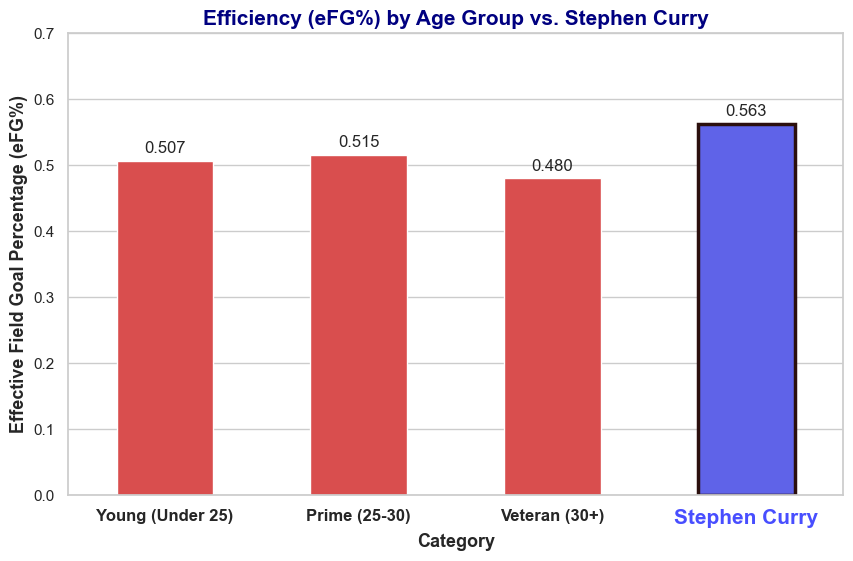

In [16]:
## ​I created this plot to visualize Stephen Curry age relative to the rest of the NBA players

## comparison data
age_means = age_analysis['eFG%'].tolist()
categories = age_analysis.index.tolist() + ['Stephen Curry']
values = age_means + [df[df['Player'] == 'Stephen Curry']['eFG%'].values[0]]

## Create Bar Chart
plt.figure(figsize=(10, 6))
colors = ['#F03737', '#F03737', '#F03737', "#484EFF"]
ax = sns.barplot(x=categories, y=values, palette=colors, width=0.5)

## Costimize Stephen Curry's Name and Bar color
labels = ax.get_xticklabels()
labels[3].set_fontweight('bold')
labels[3].set_fontsize(15)
labels[3].set_color("#484EFF")


for i in range(3):
    labels[i].set_fontweight('bold')
    labels[i].set_fontsize(12)

bar_to_highlight = ax.patches[3]
bar_to_highlight.set_edgecolor("#2B0F0D")
bar_to_highlight.set_linewidth(2.5)

## Titles and Labels
plt.title('Efficiency (eFG%) by Age Group vs. Stephen Curry', fontsize=15, fontweight='bold',color='navy')
plt.xlabel('Category', fontsize=13, fontweight='bold')
plt.ylabel('Effective Field Goal Percentage (eFG%)', fontsize=13, fontweight='bold')
plt.ylim(0, 0.7) 

## Add Data labels to bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha = 'center', va = 'center', 
            xytext = (0, 9), 
            textcoords = 'offset points')

plt.show()

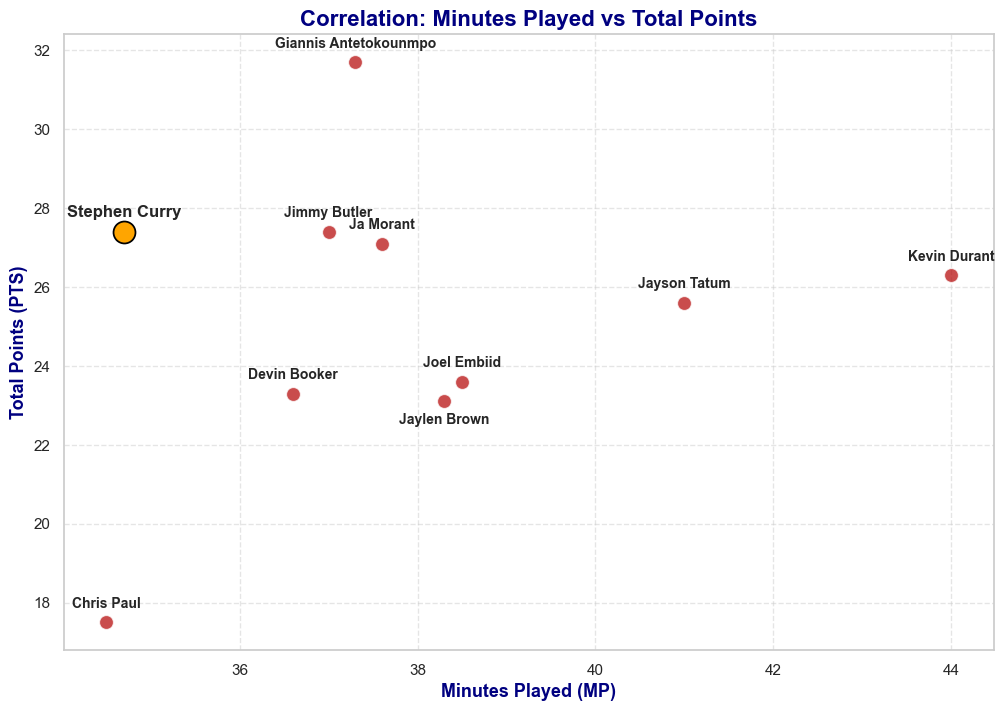

In [17]:
plt.figure(figsize=(12, 8))

## Create Scatter Plot to compare Minutes Played vs. Total Points 
sns.scatterplot(data=stars_df, x='MP', y='PTS', color="#b30000", alpha=0.7, s=100)

## Highlight Stephen Curry with a distinct color and size
steph_data = stars_df[stars_df['Player'] == 'Stephen Curry']
sns.scatterplot(data=steph_data, x='MP', y='PTS', color='#FFA500', s=250, edgecolor='black')

## Add player names with custom styling
for i in range(stars_df.shape[0]):
    player_name = stars_df.Player.iloc[i]
    player_mp = stars_df.MP.iloc[i]
    player_pts = stars_df.PTS.iloc[i]
    
    current_weight = 'semibold'
    current_size = 10
    current_offset = 0.3 #
    current_va = 'bottom' # 

    ## Set custom changes for each player
    if player_name == 'Stephen Curry':
        current_weight = 'bold'
        current_size = 12

    if player_name == 'Jaylen Brown':
        current_offset = -0.3
        current_va = 'top'
         
    ## Add the text to the plot
    plt.text(player_mp,
        player_pts + current_offset,
        player_name, 
        fontsize=current_size,  
        fontweight=current_weight, 
        ha='center', va=current_va)
## Title and Labels
plt.title('Correlation: Minutes Played vs Total Points', fontsize=16, fontweight='bold', color='navy')
plt.xlabel('Minutes Played (MP)', fontsize=13, fontweight='bold', color='navy')
plt.ylabel('Total Points (PTS)', fontsize=13, fontweight='bold', color='navy')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

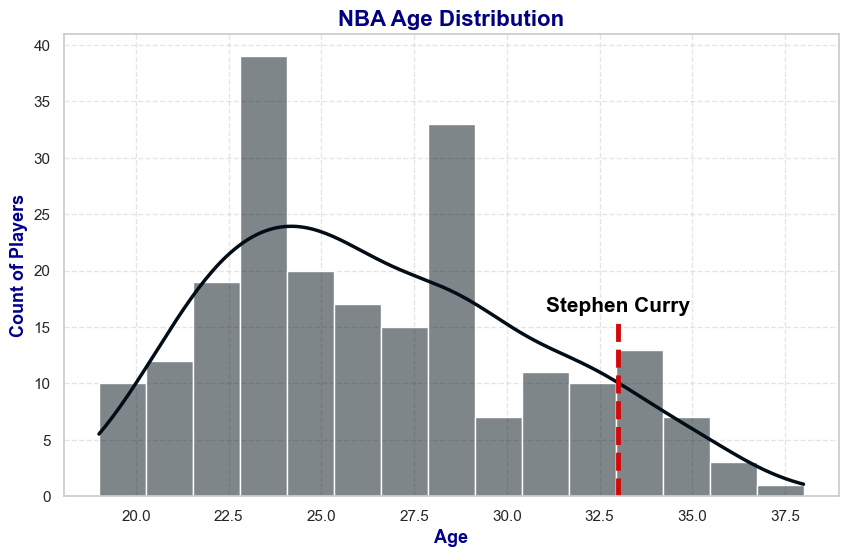

In [18]:
## Create histogram to show the NBA Age Distribution compared to Stephen Curry
plt.figure(figsize=(10, 6))

## Finds Stephen Curry exact age
steph_age = df[df['Player'] == 'Stephen Curry']['Age'].values[0]
## Plot age distribution with bars
sns.histplot(data=df, x='Age', bins=15, 
         kde=True,
         color="#010e17",
         line_kws={"color": "black", "linewidth": 2.5})

## Vilines to mark Stephen Curry age
plt.vlines(x=steph_age, 
         ymin=0, 
         ymax=16, 
         color="#D10909", 
         linestyle='--', 
         linewidth=3.5)

## Add Stephen curry above line
plt.text(steph_age, 
         16, 
         'Stephen Curry', 
         fontsize=15, 
         fontweight='bold', 
         color='black',
         ha='center', va='bottom')

## Titles and Labels
plt.title('NBA Age Distribution', fontsize=16, fontweight='bold', color='navy')
plt.xlabel('Age', fontsize=13, fontweight='bold',color='darkblue')
plt.ylabel('Count of Players', fontsize=13, fontweight='bold',color='darkblue')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

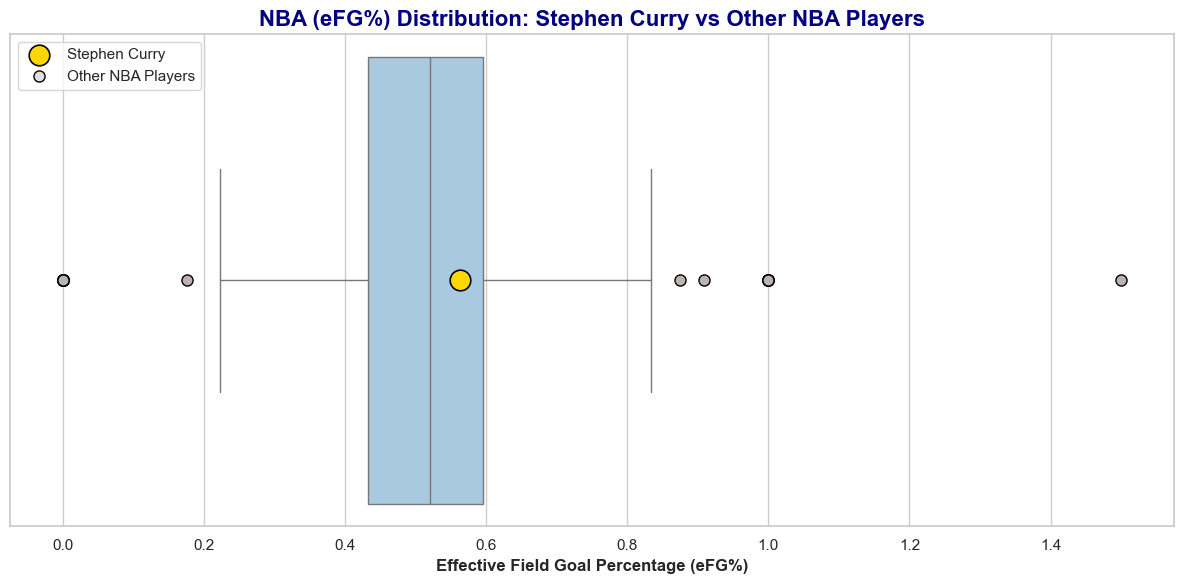

In [19]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
## create boxplot to show eFG% distribution Stephen Curry vs other NBA players  

steph_efg = df[df['Player'] == 'Stephen Curry']['eFG%'].values[0]

## create the boxplot and customize the outliers to make them more visible
ax = sns.boxplot(data=df, x='eFG%', 
                 color='#a0cbea', width=0.4, 
                 flierprops={"marker": "o", "markersize": 8, "markerfacecolor": "#BDB2B2", "markeredgecolor": "black"})

## Marks Stephen Curry with yellow dot
sns.scatterplot(x=[steph_efg], y=[0], 
                color='#FFD700', s=220,
                label='Stephen Curry', 
                edgecolor='black', zorder=10)

## Create fake dot for "Other NBA Players"
other_players_marker = mlines.Line2D([], [], color='#E0E0E0', marker='o', linestyle='None',
                markersize=8, markeredgecolor='black', label='Other NBA Players')

## Create labels for all markers
handles, current_labels = plt.gca().get_legend_handles_labels()
handles.append(other_players_marker)

plt.legend(handles=handles, loc='upper left')

## titles and labels
plt.title('NBA (eFG%) Distribution: Stephen Curry vs Other NBA Players', fontsize=16, fontweight='bold', color='navy')
plt.xlabel('Effective Field Goal Percentage (eFG%)', fontsize=12, fontweight='bold')

## Remove unnecessary vertical axis number
ax.set_ylabel('')
ax.set_yticks([])

plt.tight_layout()
plt.show()

In [20]:
## Create a combined PTS and AST metric
df['Total_Contribution'] = df['PTS'] + df['AST']

In [21]:
## Sort Top 10 players based on the metric
top_10_contribution = df.sort_values(by='Total_Contribution', ascending=False).head(10)

C:\Users\דניאל\AppData\Local\Temp\ipykernel_23024\420375366.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10_contribution, x='Total_Contribution', y='Player', palette='viridis')


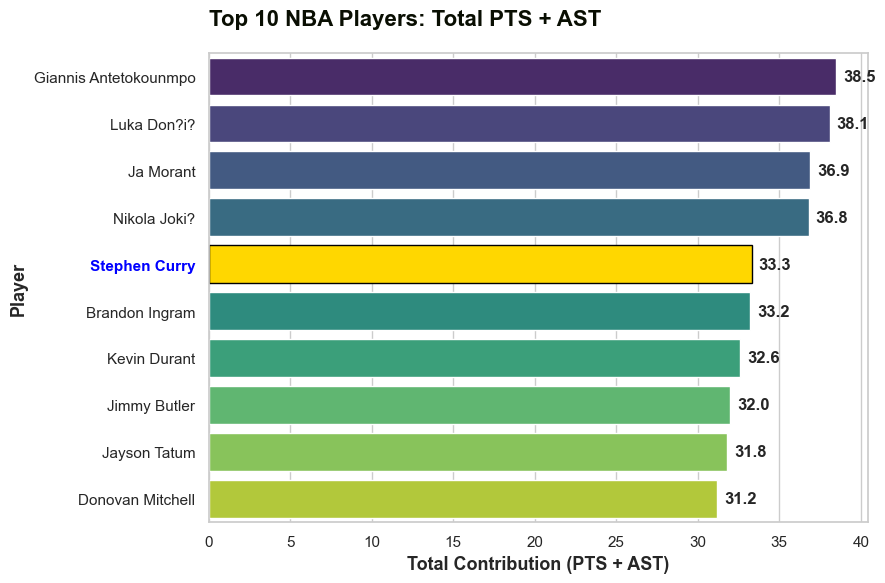

In [22]:
plt.figure(figsize=(9, 6))

## Create a horizontal bar plot Top 10 players by PTS + AST 
ax = sns.barplot(data=top_10_contribution, x='Total_Contribution', y='Player', palette='viridis')

## Entering the data at the end of each column
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=5, fontweight='bold')

## Titles and Labels
plt.title('Top 10 NBA Players: Total PTS + AST', fontsize=16, fontweight='bold', pad=20, loc='left', color="#090E02")
plt.xlabel('Total Contribution (PTS + AST)', fontsize=13, fontweight='bold')
plt.ylabel('Player', fontsize=13, fontweight='bold')

## Marks Steph Curry if he is in the top 10
for i, label in enumerate(ax.get_yticklabels()):
    if label.get_text() == 'Stephen Curry':
        ax.patches[i].set_facecolor('#FFD700')
        ax.patches[i].set_edgecolor('black')
        label.set_fontweight('bold')
        label.set_color('blue')

plt.tight_layout()
plt.show()


## **<span style="color:lightgreen">3.8 - ​Summary and Conclusions:**</span>  
--

**Efficiency Over Exhaustion: Maximizing Output in Minimum Time - Stephen Curry Playoff 2022:**  

**<span style="color: #008cff">This project examines the unique performance and efficiency of**</span>  
**<span style="color: #008cff">Stephen Curry during the 2021-2022 NBA Playoff**</span>

**Efficiency vs. Physical Workload**  
the data shows that Curry stays at a top scoring level while playing fewer   
minutes than other superstars like Kevin Durant or Nikola Jokic.   
This smart time management helps him stay fresh during a tight Playoff schedule with games every two days,   
or throughout a long 82-game season.   
By finishing games early to get more rest and playing his best in key moments,   
Curry proves that being efficient is about saving energy and staying healthy for the long run.

**The analysis identifies Stephen Curry as a significant positive outlier:**  
While the league is dominated by younger players, Curry remains highly competitive at age 33,   
leading the top 10 in eFG% while playing fewer minutes than other players.   
This suggests that his experience allows him to manage his physical workload effectively   
while maintaining elite-level production.

**Team Impact:**  
The data reveals that Curry’s influence extends far beyond his individual scoring.   
His 'offensive gravity' draws double-teams and constant defensive attention,   
creating open shots and high-percentage opportunities for his teammates.   
This is reflected in the team’s elite eFG% (0.569), the highest among all compared teams.   
Whether playing with veterans like Green and Thompson or leading the younger roster,   
Curry acts as an 'on-court coach,' balancing elite playmaking with strategic floor   
leadership to elevate the entire group's efficiency

**Research Insights:**  
**<span style="color: #008cff">​Elite Time Management:**</span>  
The research proves that effective time management for elite players is a primary driver for team success.   
By optimizing minutes and maintaining efficiency,   
a team can ensure star player remains at peak performance for the Playoffs.  
**<span style="color: #008cff">​The 'All-Around' Leader:**</span>  
A leading player must be an 'all-around god' who takes full responsibility for the team’s results.   
As shown by Curry performance, elite leadership involves balancing high individual scoring with   
the ability to elevate the entire team’s efficiency.

**Future Research Directions:**  
**<span style="color: #008cff">​Clutch Efficiency Analysis:**</span>    
A fascinating next step would be to analyze Curry efficiency (eFG\%)   
specifically in the final 2 minutes of close games.   
Comparing these 'clutch' stats to other legends in NBA history   
would show if he truly is the most reliable player under pressure.  
**<span style="color: #008cff">​Free Throw Mastery Under Pressure:**</span>    
Another key area to research is Curry Free Throw percentage (FT\%)   
in the final moments of the game. Since he is known for his focus,   
comparing his late-game shooting to other all-time greats   
would reveal his true level of mental toughness.  

**In Conclusion,**   
Stephen Curry represents the perfect balance between elite talent and smart management,   
proving that greatness is about sustainability as much as skill.   
By optimizing his workload and staying fresh for every challenge,   
he remains at the top of the league while elevating his entire team to success.  

In [23]:
df.to_csv('steph_filtered_data.csv', index=False)